<a href="https://colab.research.google.com/github/Mahanteshvn/ML_LAB/blob/main/ML_Lab_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
import io

print("Please upload your first CSV file.")
uploaded1 = files.upload()

if uploaded1:
    for fn1 in uploaded1.keys():
        df1 = pd.read_csv(io.StringIO(uploaded1[fn1].decode('utf-8')))
        print(f"File '{fn1}' uploaded and read successfully.")
        print("First 5 rows of the first DataFrame:")
        print(df1.head())
else:
    print("No first file uploaded.")

print("\nPlease upload your second CSV file.")
uploaded2 = files.upload()

if uploaded2:
    for fn2 in uploaded2.keys():
        df2 = pd.read_csv(io.StringIO(uploaded2[fn2].decode('utf-8')))
        print(f"File '{fn2}' uploaded and read successfully.")
        print("First 5 rows of the second DataFrame:")
        print(df2.head())
else:
    print("No second file uploaded.")

# The dataframes are now stored in df1 and df2 (if files were uploaded)
# You can access them and perform further operations.
# Example: print(df1.info())
# Example: print(df2.describe())

Please upload your first CSV file.


Saving deliveries.csv to deliveries.csv
File 'deliveries.csv' uploaded and read successfully.
First 5 rows of the first DataFrame:
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  

Saving matches.csv to matches.csv
File 'matches.csv' uploaded and read successfully.
First 5 rows of the second DataFrame:
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens   

In [ ]:
import pandas as pd

# Merge df1 (deliveries) and df2 (matches) on a common ID
# It appears match_id in df1 corresponds to id in df2
df_merged = pd.merge(df1, df2, left_on='match_id', right_on='id', how='left')

print("Merged DataFrame shape:", df_merged.shape)
print("\nMerged DataFrame Info:")
df_merged.info()

print("\nMissing values in the merged DataFrame:")
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

print("\nFirst 5 rows of the merged DataFrame:")
print(df_merged.head())

Merged DataFrame shape: (260920, 37)

Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 37 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          260920 non-null  int64  
 1   inning            260920 non-null  int64  
 2   batting_team      260920 non-null  object 
 3   bowling_team      260920 non-null  object 
 4   over              260920 non-null  int64  
 5   ball              260920 non-null  int64  
 6   batter            260920 non-null  object 
 7   bowler            260920 non-null  object 
 8   non_striker       260920 non-null  object 
 9   batsman_runs      260920 non-null  int64  
 10  extra_runs        260920 non-null  int64  
 11  total_runs        260920 non-null  int64  
 12  extras_type       14125 non-null   object 
 13  is_wicket         260920 non-null  int64  
 14  player_dismissed  12950 non-null   object 
 15  dismiss

In [ ]:
import pandas as pd

# Fill missing values in 'winner' column with 'No Result'
df_merged['winner'] = df_merged['winner'].fillna('No Result')

# Fill missing values in 'result_margin' column with 0
df_merged['result_margin'] = df_merged['result_margin'].fillna(0)

print("Missing values after handling:")
print(df_merged[['winner', 'result_margin']].isnull().sum())

Missing values after handling:
winner           0
result_margin    0
dtype: int64


In [ ]:
print("Missing values across all columns in df_merged:")
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Missing values across all columns in df_merged:
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
city                 12397
player_of_match        490
target_runs            309
target_overs           309
method              257274
dtype: int64


In [ ]:
# Drop columns with very high missing values and less direct relevance for match-level prediction
columns_to_drop = ['extras_type', 'player_dismissed', 'dismissal_kind', 'fielder', 'method']
df_merged = df_merged.drop(columns=columns_to_drop)

# Fill missing values for 'city' and 'player_of_match' with 'Unknown'
df_merged['city'] = df_merged['city'].fillna('Unknown')
df_merged['player_of_match'] = df_merged['player_of_match'].fillna('Unknown')

# Fill missing values for numerical target columns with 0
df_merged['target_runs'] = df_merged['target_runs'].fillna(0)
df_merged['target_overs'] = df_merged['target_overs'].fillna(0)

print("Missing values after dropping and imputation:")
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Missing values after dropping and imputation:
Series([], dtype: int64)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create a match-level DataFrame from df_merged
df_matches = df_merged[['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
                        'venue', 'team1', 'team2', 'toss_winner', 'toss_decision',
                        'winner', 'result', 'result_margin', 'target_runs', 'target_overs',
                        'super_over', 'umpire1', 'umpire2']].drop_duplicates(subset=['id']).copy()

# Convert 'date' column to datetime type to extract day of week
df_matches['date'] = pd.to_datetime(df_matches['date'])
df_matches['day_of_week'] = df_matches['date'].dt.day_name() # Extract day name

print("Shape of df_matches (match-level data):", df_matches.shape)
print("\nFirst 5 rows of df_matches:")
print(df_matches.head())

# Define features (X) and target (y)
# Select features that are available before the match outcome is known
X = df_matches[['season', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'match_type', 'day_of_week']]
y = df_matches['winner']

# Convert categorical features into numerical using one-hot encoding
X = pd.get_dummies(X, columns=['season', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'match_type', 'day_of_week'], drop_first=True)

print("\nShape of X after one-hot encoding:", X.shape)
print("\nFirst 5 rows of X (features):")
print(X.head())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set shape (X_train, y_train):")
print(X_train.shape, y_train.shape)
print("\nTest set shape (X_test, y_test):")
print(X_test.shape, y_test.shape)

# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Using class_weight for potential imbalance
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nRandom Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Shape of df_matches (match-level data): (1095, 20)

First 5 rows of df_matches:
         id   season        city       date match_type player_of_match  \
0    335982  2007/08   Bangalore 2008-04-18     League     BB McCullum   
225  335983  2007/08  Chandigarh 2008-04-19     League      MEK Hussey   
473  335984  2007/08       Delhi 2008-04-19     League     MF Maharoof   
692  335985  2007/08      Mumbai 2008-04-20     League      MV Boucher   
938  335986  2007/08     Kolkata 2008-04-20     League       DJ Hussey   

                                          venue                        team1  \
0                         M Chinnaswamy Stadium  Royal Challengers Bangalore   
225  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
473                            Feroz Shah Kotla             Delhi Daredevils   
692                            Wankhede Stadium               Mumbai Indians   
938                                Eden Gardens        Kolkata Knight Rider

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aggregate total runs per inning from df_merged
inning_scores = df_merged.groupby(['id', 'inning', 'batting_team', 'bowling_team']).agg(
    inning_total_runs=('total_runs', 'sum')
).reset_index()

# For this example, let's predict the score of the first inning.
# Filter for first innings
first_inning_scores = inning_scores[inning_scores['inning'] == 1].copy()

# Merge with df_matches to get match-level features
# Dropping columns from df_matches that are either duplicates or not relevant for predicting 1st inning score
df_regression = pd.merge(first_inning_scores,
                         df_matches.drop(columns=['winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'player_of_match', 'umpire1', 'umpire2', 'team1', 'team2']),
                         on='id',
                         how='left')

print("Shape of df_regression (inning-level data for regression):", df_regression.shape)
print("\nFirst 5 rows of df_regression:")
print(df_regression.head())

Shape of df_regression (inning-level data for regression): (1095, 14)

First 5 rows of df_regression:
       id  inning           batting_team                 bowling_team  \
0  335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
1  335983       1    Chennai Super Kings              Kings XI Punjab   
2  335984       1       Rajasthan Royals             Delhi Daredevils   
3  335985       1         Mumbai Indians  Royal Challengers Bangalore   
4  335986       1        Deccan Chargers        Kolkata Knight Riders   

   inning_total_runs   season        city       date match_type  \
0                222  2007/08   Bangalore 2008-04-18     League   
1                240  2007/08  Chandigarh 2008-04-19     League   
2                129  2007/08       Delhi 2008-04-19     League   
3                165  2007/08      Mumbai 2008-04-20     League   
4                110  2007/08     Kolkata 2008-04-20     League   

                                        venue           

In [ ]:
import numpy as np

# Define features (X) and target (y)
X_reg = df_regression[['season', 'city', 'venue', 'batting_team', 'bowling_team', 'toss_winner', 'toss_decision', 'match_type', 'day_of_week']]
y_reg = df_regression['inning_total_runs']

# Convert categorical features into numerical using one-hot encoding
X_reg = pd.get_dummies(X_reg, columns=['season', 'city', 'venue', 'batting_team', 'bowling_team', 'toss_winner', 'toss_decision', 'match_type', 'day_of_week'], drop_first=True)

print("\nShape of X_reg after one-hot encoding:", X_reg.shape)

# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("\nTraining set shape (X_train_reg, y_train_reg):")
print(X_train_reg.shape, y_train_reg.shape)
print("\nTest set shape (X_test_reg, y_test_reg):")
print(X_test_reg.shape, y_test_reg.shape)

# Initialize and train the Random Forest Regressor
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = reg_model.predict(X_test_reg)

# Evaluate the model
print("\nRandom Forest Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_reg):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_reg):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.2f}")
print(f"R-squared (R2): {r2_score(y_test_reg, y_pred_reg):.2f}")

# Display some predictions vs actual
results_df_reg = pd.DataFrame({'Actual': y_test_reg, 'Predicted': y_pred_reg})
print("\nFirst 10 Actual vs Predicted Scores:")
print(results_df_reg.head(10))


Shape of X_reg after one-hot encoding: (1095, 177)

Training set shape (X_train_reg, y_train_reg):
(876, 177) (876,)

Test set shape (X_test_reg, y_test_reg):
(219, 177) (219,)

Random Forest Regressor Performance:
Mean Absolute Error (MAE): 25.49
Mean Squared Error (MSE): 1015.59
Root Mean Squared Error (RMSE): 31.87
R-squared (R2): -0.08

First 10 Actual vs Predicted Scores:
      Actual  Predicted
533      164     173.19
139      172     161.93
88       105     167.61
841      179     141.13
985      200     200.90
1037     125     179.30
286      100     159.38
602      188     165.85
1089     218     179.32
715      149     167.80


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_linear_reg = linear_reg_model.predict(X_test_reg)

# Evaluate the model
print("\nLinear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_linear_reg):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_linear_reg):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_reg, y_pred_linear_reg)):.2f}")
print(f"R-squared (R2): {r2_score(y_test_reg, y_pred_linear_reg):.2f}")

# Display some predictions vs actual
results_df_linear_reg = pd.DataFrame({'Actual': y_test_reg, 'Predicted': y_pred_linear_reg})
print("\nFirst 10 Actual vs Predicted Scores (Linear Regression):")
print(results_df_linear_reg.head(10))


Linear Regression Model Performance:
Mean Absolute Error (MAE): 26.65
Mean Squared Error (MSE): 1172.79
Root Mean Squared Error (RMSE): 34.25
R-squared (R2): -0.25

First 10 Actual vs Predicted Scores (Linear Regression):
      Actual   Predicted
533      164  165.110084
139      172  164.834615
88       105  161.629162
841      179  152.115447
985      200  193.909260
1037     125  204.100456
286      100  166.236901
602      188  172.103839
1089     218  186.401743
715      149  175.449328


Top 10 Feature Importances from Random Forest Regressor:
                           Feature  Importance
15                     season_2024    0.045810
14                     season_2023    0.026616
172           day_of_week_Saturday    0.025354
176          day_of_week_Wednesday    0.022075
173             day_of_week_Sunday    0.020366
163            toss_decision_field    0.019787
171             day_of_week_Monday    0.019061
121  batting_team_Rajasthan Royals    0.017453
174           day_of_week_Thursday    0.017358
136    bowling_team_Mumbai Indians    0.015496


/tmp/ipykernel_4327/4273463608.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')


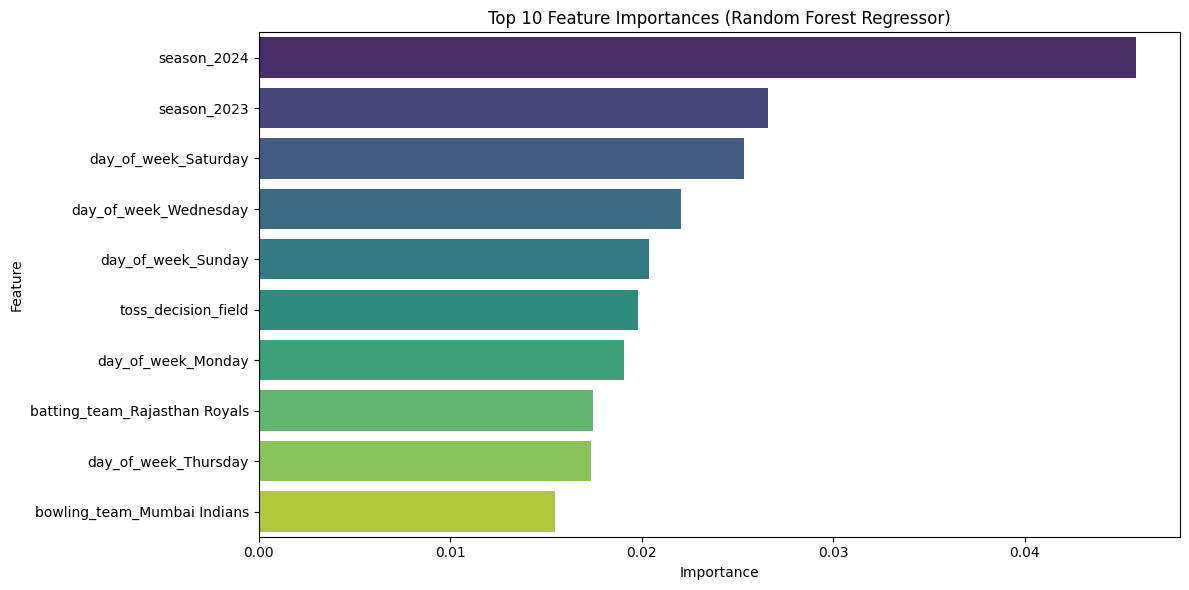

In [ ]:
import pandas as pd

# Get feature importances from the Random Forest Regressor model
feature_importances = reg_model.feature_importances_

# Create a Series with feature names and their importance scores
features_df = pd.DataFrame({'Feature': X_reg.columns, 'Importance': feature_importances})

# Sort the features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances from Random Forest Regressor:")
print(features_df.head(10))

# Optionally, visualize feature importances
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest Regressor)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Comparison of Random Forest Regressor and Linear Regression Model Performance

Let's summarize the performance metrics for both models:

| Metric                    | Random Forest Regressor | Linear Regression Model |
| :------------------------ | :---------------------- | :---------------------- |
| **Mean Absolute Error (MAE)** | 25.49                   | 26.65                   |
| **Mean Squared Error (MSE)**  | 1015.59                 | 1172.79                 |
| **Root Mean Squared Error (RMSE)** | 31.87                   | 34.25                   |
| **R-squared (R2)**        | -0.08                   | -0.25                   |

**Analysis:**

*   **Random Forest Regressor** generally performed slightly better than the **Linear Regression Model** across all evaluated metrics (MAE, MSE, RMSE).
*   Both models exhibit **poor predictive performance**, indicated by their low and negative R-squared values. An R2 of less than 0 suggests that the model is performing worse than simply predicting the mean of the target variable for all instances. This indicates that the current set of features and the chosen models are not capturing enough variance in the target variable (inning total runs).

**Conclusion:**

Based on these metrics, the **Random Forest Regressor** is marginally better than the Linear Regression model for this specific task and dataset. However, both models require significant improvement. Future steps should focus on:

1.  **Feature Engineering:** Deriving more impactful features that might better explain the variation in inning scores (e.g., historical team performance, average scores at a venue, recent form of opening batsmen, pitch conditions).
2.  **Model Selection:** Exploring other advanced regression techniques.
3.  **Hyperparameter Tuning:** Optimizing the parameters of the chosen models.

/tmp/ipykernel_4327/1105814688.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Score', data=performance_df_melted[performance_df_melted['Metric'] == metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_4327/1105814688.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Score', data=performance_df_melted[performance_df_melted['Metric'] == metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_4327/1105814688.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Score', data=performance_df_melte

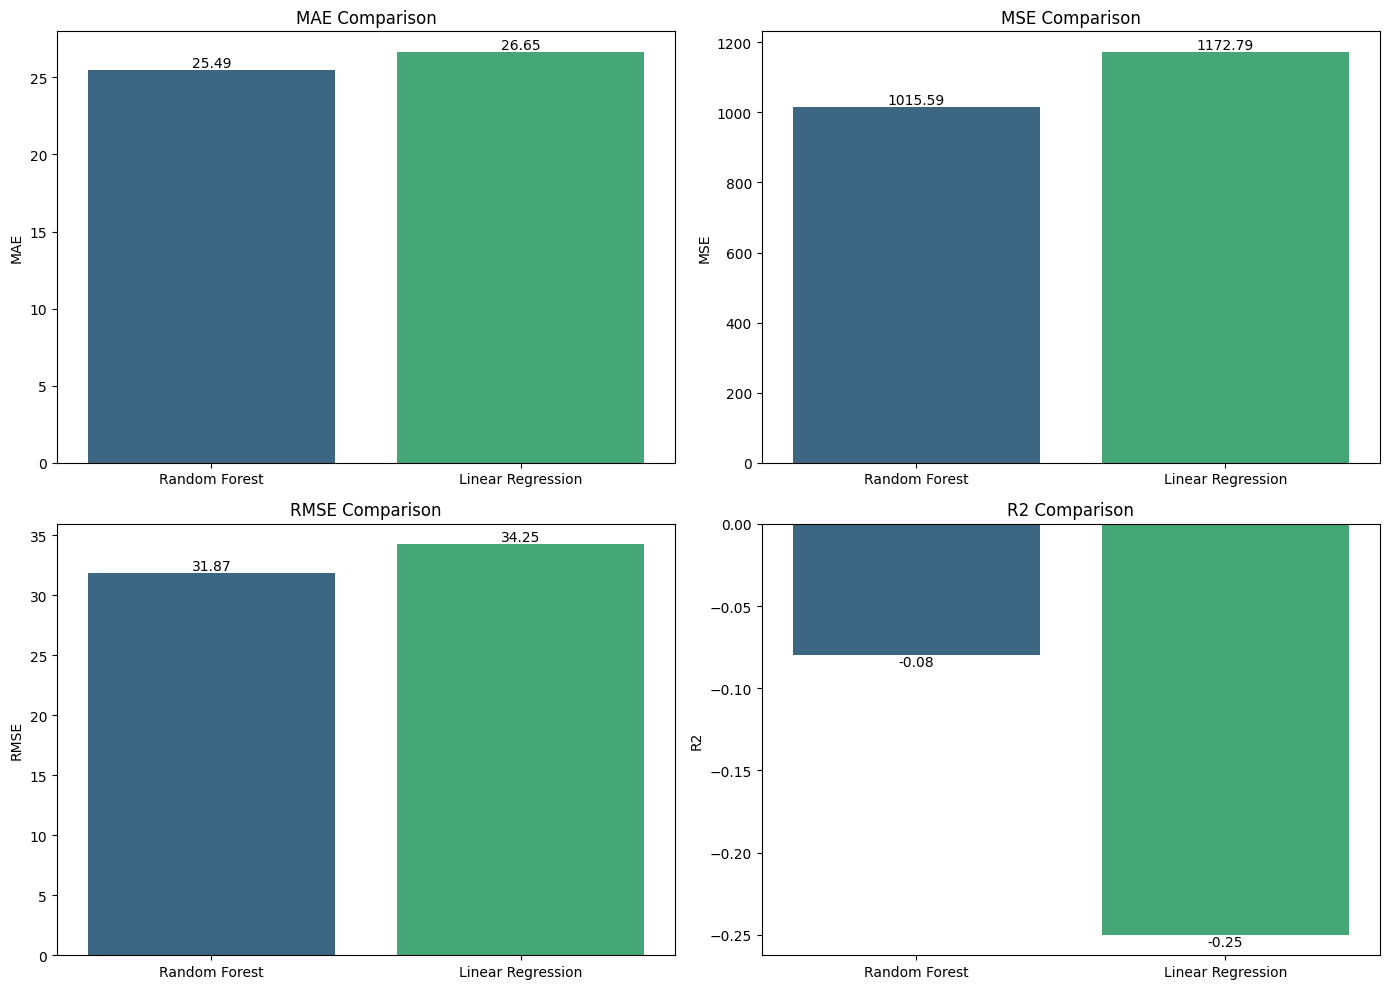

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Model performance data
metrics = ['MAE', 'MSE', 'RMSE', 'R2']
rf_performance = [25.49, 1015.59, 31.87, -0.08]
linear_reg_performance = [26.65, 1172.79, 34.25, -0.25]

# Create a DataFrame for easy plotting
performance_df = pd.DataFrame({
    'Metric': metrics,
    'Random Forest': rf_performance,
    'Linear Regression': linear_reg_performance
})

performance_df_melted = performance_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y='Score', data=performance_df_melted[performance_df_melted['Metric'] == metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')

    # Add value labels on top of the bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Why Random Forest Regressor Performed Better

The Random Forest Regressor was considered marginally better than the Linear Regression model for predicting first inning scores based on the following direct comparison of their evaluation metrics:

*   **Mean Absolute Error (MAE):**
    *   Random Forest: **25.49**
    *   Linear Regression: **26.65**
    *   *Interpretation:* A lower MAE indicates better performance, as it means, on average, the predictions are closer to the actual values. The Random Forest had a slightly lower MAE.

*   **Mean Squared Error (MSE):**
    *   Random Forest: **1015.59**
    *   Linear Regression: **1172.79**
    *   *Interpretation:* A lower MSE signifies fewer large errors and better overall accuracy. The Random Forest had a lower MSE.

*   **Root Mean Squared Error (RMSE):**
    *   Random Forest: **31.87**
    *   Linear Regression: **34.25**
    *   *Interpretation:* A lower RMSE also indicates a more accurate model, as it represents the standard deviation of the prediction errors. The Random Forest had a lower RMSE.

*   **R-squared (R2):**
    *   Random Forest: **-0.08**
    *   Linear Regression: **-0.25**
    *   *Interpretation:* While both models had negative R2 values (indicating poor fit), Random Forest's R2 was less negative (closer to zero) than Linear Regression's. An R2 closer to zero (or positive) indicates a model that explains more of the variance in the target variable. Even a negative R2 for Random Forest is 'less bad' than the more negative R2 of Linear Regression.

Across all these metrics, the Random Forest Regressor consistently showed slightly better performance (lower error or less negative R2), leading to the conclusion that it is the superior model between the two for this task, despite both models having significant room for improvement.